# Deepfake Detection: CNN + ViT + FFT + Temporal LSTM

This notebook upgrades the frame-only hybrid model to a **video-level** model using:
- Spatial features: ResNet50 + ViT
- Frequency features: FFT artifact branch
- Temporal modeling: BiLSTM over frame sequences

It also includes tunable fraction controls so you can train on smaller subsets first.

In [1]:
import os
import re
import time
import random
from pathlib import Path
from collections import defaultdict

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import timm
from tqdm import tqdm

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    roc_curve,
    auc,
)
import matplotlib.pyplot as plt

In [ ]:
# =========================
# Config
# =========================
SEED = 42
DATA_PATH = Path("../data/FF_frames")

# Fraction controls
FRACTION = 1.00          # train fraction (0 < FRACTION <= 1)
VAL_FRACTION = 1.00      # keep full validation for stable metric

VAL_RATIO = 0.20         # video-level split
SEQ_LEN = 8              # frames per sequence
SEQ_STRIDE = 2           # denser windows improve temporal learning

BATCH_SIZE = 2
NUM_WORKERS = 0          # Windows-safe
EPOCHS = 8
LR = 3e-4
WEIGHT_DECAY = 1e-4
FREEZE_BACKBONES = True

# Stability knobs
USE_CLASS_WEIGHTS = True
LABEL_SMOOTHING = 0.05
LSTM_HIDDEN = 192
FFT_DIM = 128
TEMPORAL_POOL = "mean"  # "mean" is usually more stable than last-step only
EARLY_STOP_PATIENCE = 3

# Temporal models are sensitive to per-frame random augment mismatch
TRAIN_AUGMENT = "temporal_safe"  # "temporal_safe" | "none"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("Using device:", DEVICE)
print("Data path:", DATA_PATH)
print("FRACTION:", FRACTION, "VAL_FRACTION:", VAL_FRACTION)
print("TRAIN_AUGMENT:", TRAIN_AUGMENT)

Using device: cpu
Data path: ..\data\FF_frames
FRACTION: 0.3 VAL_FRACTION: 1.0
TRAIN_AUGMENT: temporal_safe


In [ ]:
# transforms are deterministic per frame to avoid synthetic motion artifacts across sequence steps
if TRAIN_AUGMENT == "none":
    train_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])
else:
    train_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

In [4]:
# =========================
# Data indexing helpers
# =========================
_FRAME_RE = re.compile(r"^(.*)_(\d+)\.(jpg|jpeg|png)$", re.IGNORECASE)

def parse_video_id_and_frame_idx(filename: str):
    m = _FRAME_RE.match(filename)
    if not m:
        return None, None
    video_id = m.group(1)
    frame_idx = int(m.group(2))
    return video_id, frame_idx

def build_video_records(data_path: Path, min_frames: int = 8):
    class_names = sorted([d.name for d in data_path.iterdir() if d.is_dir()])
    class_to_idx = {name: i for i, name in enumerate(class_names)}

    # key -> record
    # key format: class_name/video_id
    video_map = {}

    for class_name in class_names:
        class_dir = data_path / class_name
        for p in class_dir.glob("*"):
            if not p.is_file():
                continue
            video_id, frame_idx = parse_video_id_and_frame_idx(p.name)
            if video_id is None:
                continue

            key = f"{class_name}/{video_id}"
            if key not in video_map:
                video_map[key] = {
                    "video_id": video_id,
                    "label_name": class_name,
                    "label": class_to_idx[class_name],
                    "frames": [],
                }

            video_map[key]["frames"].append((frame_idx, p))

    video_records = []
    for rec in video_map.values():
        rec["frames"] = [p for _, p in sorted(rec["frames"], key=lambda x: x[0])]
        if len(rec["frames"]) >= min_frames:
            video_records.append(rec)

    return video_records, class_names, class_to_idx

def split_video_records(video_records, val_ratio=0.2, seed=42):
    rng = random.Random(seed)
    by_label = defaultdict(list)
    for rec in video_records:
        by_label[rec["label"]].append(rec)

    train_records, val_records = [], []
    for _, recs in by_label.items():
        rng.shuffle(recs)
        n_val = max(1, int(len(recs) * val_ratio))
        val_records.extend(recs[:n_val])
        train_records.extend(recs[n_val:])

    rng.shuffle(train_records)
    rng.shuffle(val_records)
    return train_records, val_records

def make_sequence_samples(video_records, seq_len=8, seq_stride=4):
    samples = []
    for rec in video_records:
        frames = rec["frames"]
        for start in range(0, len(frames) - seq_len + 1, seq_stride):
            seq_paths = frames[start:start + seq_len]
            samples.append({
                "video_id": rec["video_id"],
                "label": rec["label"],
                "label_name": rec["label_name"],
                "frame_paths": seq_paths,
            })
    return samples

def apply_fraction_balanced(samples, fraction=1.0, seed=42):
    if fraction >= 1.0:
        return samples
    if fraction <= 0:
        raise ValueError("fraction must be > 0")

    rng = random.Random(seed)
    by_label = defaultdict(list)
    for s in samples:
        by_label[s["label"]].append(s)

    picked = []
    for _, group in by_label.items():
        rng.shuffle(group)
        n = max(1, int(len(group) * fraction))
        picked.extend(group[:n])

    rng.shuffle(picked)
    return picked

def count_labels(samples, class_names):
    counts = {name: 0 for name in class_names}
    for s in samples:
        counts[class_names[s["label"]]] += 1
    return counts

class FrameSequenceDataset(Dataset):
    def __init__(self, samples, transform=None):
        self.samples = samples
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        rec = self.samples[idx]
        frames = []
        for path in rec["frame_paths"]:
            img = Image.open(path).convert("RGB")
            if self.transform is not None:
                img = self.transform(img)
            frames.append(img)

        x = torch.stack(frames, dim=0)  # [T, C, H, W]
        y = torch.tensor(rec["label"], dtype=torch.long)
        return x, y

In [16]:
video_records, class_names, class_to_idx = build_video_records(DATA_PATH, min_frames=SEQ_LEN)
train_videos, val_videos = split_video_records(video_records, val_ratio=VAL_RATIO, seed=SEED)

train_samples = make_sequence_samples(train_videos, seq_len=SEQ_LEN, seq_stride=SEQ_STRIDE)
val_samples = make_sequence_samples(val_videos, seq_len=SEQ_LEN, seq_stride=SEQ_STRIDE)

train_samples = apply_fraction_balanced(train_samples, fraction=FRACTION, seed=SEED)
val_samples = apply_fraction_balanced(val_samples, fraction=VAL_FRACTION, seed=SEED)

train_dataset = FrameSequenceDataset(train_samples, transform=train_transform)
val_dataset = FrameSequenceDataset(val_samples, transform=val_transform)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

print("Classes:", class_names)
print("Videos total:", len(video_records))
print("Train videos:", len(train_videos), "Val videos:", len(val_videos))
print("Train sequences:", len(train_dataset), "Val sequences:", len(val_dataset))
print("Train class balance:", count_labels(train_samples, class_names))
print("Val class balance:", count_labels(val_samples, class_names))

Classes: ['fake', 'real']
Videos total: 398
Train videos: 319 Val videos: 79
Train sequences: 3490 Val sequences: 2732
Train class balance: {'fake': 1608, 'real': 1882}
Val class balance: {'fake': 1154, 'real': 1578}


In [22]:
# Diversity diagnostics: sequence-level fraction can collapse unique-video coverage
def summarize_video_diversity(samples, split_name):
    by_video = defaultdict(int)
    for s in samples:
        by_video[s["video_id"]] += 1

    counts = np.array(list(by_video.values()), dtype=np.int64) if by_video else np.array([0])
    print(f"[{split_name}] Unique videos in samples: {len(by_video)}")
    print(f"[{split_name}] Seq/video -> min={counts.min()} median={np.median(counts):.1f} max={counts.max()}")

    top_videos = sorted(by_video.items(), key=lambda kv: kv[1], reverse=True)[:5]
    print(f"[{split_name}] Top-5 videos by sequence count:", top_videos)

summarize_video_diversity(train_samples, "train")
summarize_video_diversity(val_samples, "val")

[train] Unique videos in samples: 319
[train] Seq/video -> min=1 median=11.0 max=26
[train] Top-5 videos by sequence count: [('03__talking_angry_couch', 26), ('14__talking_angry_couch', 26), ('01__talking_angry_couch', 26), ('03_27__walking_down_indoor_hall_disgust__IL675GCI', 25), ('10__talking_angry_couch', 25)]
[val] Unique videos in samples: 79
[val] Seq/video -> min=7 median=34.0 max=78
[val] Top-5 videos by sequence count: [('11__talking_angry_couch', 78), ('07__talking_angry_couch', 78), ('03__walking_down_indoor_hall_disgust', 70), ('06__walking_down_indoor_hall_disgust', 66), ('06_12__podium_speech_happy__0VR4Y891', 59)]


In [17]:
# =========================
# Model: Spatial + FFT + Temporal
# =========================
class FFTBranch(nn.Module):
    def __init__(self, out_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(16),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Linear(64, out_dim),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        # x: [B, T, C, H, W] (ImageNet-normalized RGB)
        b, t, c, h, w = x.shape

        # Undo ImageNet normalization for cleaner frequency signals
        mean = x.new_tensor([0.485, 0.456, 0.406]).view(1, 1, 3, 1, 1)
        std = x.new_tensor([0.229, 0.224, 0.225]).view(1, 1, 3, 1, 1)
        x_rgb = (x * std + mean).clamp(0, 1)

        gray = x_rgb.mean(dim=2)  # [B, T, H, W]
        fft = torch.fft.fft2(gray.float(), norm="ortho")
        fft = torch.fft.fftshift(fft, dim=(-2, -1))
        mag = torch.log1p(torch.abs(fft))

        # Per-frame normalization helps training stability
        mag = (mag - mag.mean(dim=(-2, -1), keepdim=True)) / (mag.std(dim=(-2, -1), keepdim=True) + 1e-6)

        mag = mag.unsqueeze(2).reshape(b * t, 1, h, w)
        feat = self.net(mag).reshape(b, t, -1)
        return feat

class TemporalHybridModel(nn.Module):
    def __init__(
        self,
        num_classes=2,
        fft_dim=128,
        lstm_hidden=192,
        freeze_backbones=True,
        temporal_pool="mean",
    ):
        super().__init__()
        self.freeze_backbones = freeze_backbones
        self.temporal_pool = temporal_pool

        # Spatial backbones
        self.cnn = timm.create_model("resnet50", pretrained=True, num_classes=0, global_pool="avg")
        self.vit = timm.create_model("vit_base_patch16_224", pretrained=True, num_classes=0)

        if self.freeze_backbones:
            for p in self.cnn.parameters():
                p.requires_grad = False
            for p in self.vit.parameters():
                p.requires_grad = False

            # Keep frozen backbones in eval mode to avoid BN/Dropout drift.
            self.cnn.eval()
            self.vit.eval()

        self.fft_branch = FFTBranch(out_dim=fft_dim)

        # 2048 (resnet50) + 768 (vit_base) + fft_dim
        temporal_in_dim = 2048 + 768 + fft_dim
        self.temporal_norm = nn.LayerNorm(temporal_in_dim)

        self.temporal = nn.LSTM(
            input_size=temporal_in_dim,
            hidden_size=lstm_hidden,
            num_layers=1,
            batch_first=True,
            bidirectional=True,
)

        self.classifier = nn.Sequential(
            nn.LayerNorm(lstm_hidden * 2),
            nn.Linear(lstm_hidden * 2, 256),
            nn.GELU(),
            nn.Dropout(0.35),
            nn.Linear(256, num_classes),
        )

    def train(self, mode=True):
        super().train(mode)
        if self.freeze_backbones:
            # Force frozen feature extractors to stay in eval mode while head trains.
            self.cnn.eval()
            self.vit.eval()
        return self

    def forward(self, x):
        # x: [B, T, C, H, W]
        b, t, c, h, w = x.shape
        x_bt = x.reshape(b * t, c, h, w)

        if self.freeze_backbones:
            with torch.no_grad():
                cnn_feat = self.cnn(x_bt)
                vit_feat = self.vit(x_bt)
        else:
            cnn_feat = self.cnn(x_bt)
            vit_feat = self.vit(x_bt)

        cnn_feat = cnn_feat.reshape(b, t, -1)
        vit_feat = vit_feat.reshape(b, t, -1)
        fft_feat = self.fft_branch(x)

        seq_feat = torch.cat([cnn_feat, vit_feat, fft_feat], dim=-1)
        seq_feat = self.temporal_norm(seq_feat)

        lstm_out, _ = self.temporal(seq_feat)

        if self.temporal_pool == "mean":
            temporal_repr = lstm_out.mean(dim=1)
        else:
            temporal_repr = lstm_out[:, -1, :]

        logits = self.classifier(temporal_repr)
        return logits

def count_trainable_params(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable

In [18]:
model = TemporalHybridModel(
    num_classes=len(class_names),
    fft_dim=FFT_DIM,
    lstm_hidden=LSTM_HIDDEN,
    freeze_backbones=FREEZE_BACKBONES,
    temporal_pool=TEMPORAL_POOL,
).to(DEVICE)

# Class weights from sequence-level training distribution
train_labels = np.array([s["label"] for s in train_samples], dtype=np.int64)
class_counts = np.bincount(train_labels, minlength=len(class_names))
safe_counts = np.maximum(class_counts, 1)
inv_freq = safe_counts.sum() / (len(class_names) * safe_counts)
class_weights = torch.tensor(inv_freq, dtype=torch.float32, device=DEVICE)

if USE_CLASS_WEIGHTS:
    criterion = nn.CrossEntropyLoss(
        weight=class_weights,
        label_smoothing=LABEL_SMOOTHING,
    )
else:
    criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)

optimizer = torch.optim.AdamW(
    [p for p in model.parameters() if p.requires_grad],
    lr=LR,
    weight_decay=WEIGHT_DECAY,
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", factor=0.5, patience=1, min_lr=1e-6
)

total_params, trainable_params = count_trainable_params(model)
print(f"Total params: {total_params:,}")
print(f"Trainable params: {trainable_params:,}")
print("Class names:", class_names)
print("Class counts:", class_counts.tolist())
print("Class weights:", class_weights.detach().cpu().numpy().round(4).tolist())

Total params: 114,264,114
Trainable params: 4,957,426
Class names: ['fake', 'real']
Class counts: [1608, 1882]
Class weights: [1.0851999521255493, 0.9272000193595886]


In [19]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    all_preds = []
    all_labels = []

    loop = tqdm(loader, desc="Training", leave=False)
    for x, y in loop:
        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        running_loss += loss.item() * x.size(0)
        preds = torch.argmax(logits, dim=1)

        all_preds.extend(preds.detach().cpu().numpy().tolist())
        all_labels.extend(y.detach().cpu().numpy().tolist())

        loop.set_postfix(loss=loss.item())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)
    return epoch_loss, epoch_acc

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_labels = []
    all_pos_probs = []

    loop = tqdm(loader, desc="Validation", leave=False)
    for x, y in loop:
        x = x.to(device)
        y = y.to(device)

        logits = model(x)
        loss = criterion(logits, y)

        running_loss += loss.item() * x.size(0)

        probs = torch.softmax(logits, dim=1)
        preds = torch.argmax(probs, dim=1)

        all_preds.extend(preds.detach().cpu().numpy().tolist())
        all_labels.extend(y.detach().cpu().numpy().tolist())

        if probs.shape[1] == 2:
            all_pos_probs.extend(probs[:, 1].detach().cpu().numpy().tolist())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)

    return epoch_loss, epoch_acc, all_labels, all_preds, all_pos_probs

In [9]:
history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
    "lr": [],
}

best_val_acc = 0.0
best_val_loss = float("inf")
patience_counter = 0
best_ckpt = "small_cnn_vit_fft_lstm_model.pth"

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch + 1}/{EPOCHS}")
    start = time.time()

    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)
    val_loss, val_acc, _, _, _ = evaluate(model, val_loader, criterion, DEVICE)

    # Reduce LR when validation accuracy stalls
    scheduler.step(val_acc)
    current_lr = optimizer.param_groups[0]["lr"]

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["lr"].append(current_lr)

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.4f}")
    print(f"LR: {current_lr:.6f}")
    print(f"Epoch Time: {(time.time() - start) / 60:.2f} min")

    improved = (val_acc > best_val_acc + 1e-4) or (abs(val_acc - best_val_acc) <= 1e-4 and val_loss < best_val_loss)

    if improved:
        best_val_acc = val_acc
        best_val_loss = val_loss
        patience_counter = 0

        torch.save({
            "model_state_dict": model.state_dict(),
            "class_names": class_names,
            "config": {
                "seq_len": SEQ_LEN,
                "seq_stride": SEQ_STRIDE,
                "fraction": FRACTION,
                "val_fraction": VAL_FRACTION,
                "freeze_backbones": FREEZE_BACKBONES,
                "fft_dim": FFT_DIM,
                "lstm_hidden": LSTM_HIDDEN,
                "temporal_pool": TEMPORAL_POOL,
                "label_smoothing": LABEL_SMOOTHING,
                "use_class_weights": USE_CLASS_WEIGHTS,
            },
        }, best_ckpt)
        print("Saved best model ->", best_ckpt)
    else:
        patience_counter += 1
        print(f"No val improvement. Patience: {patience_counter}/{EARLY_STOP_PATIENCE}")
        if patience_counter >= EARLY_STOP_PATIENCE:
            print("Early stopping triggered.")
            break

print(f"\nBest Validation Accuracy: {best_val_acc:.4f}")
print(f"Best Validation Loss: {best_val_loss:.4f}")


Epoch 1/6


Train Loss: 0.6888 | Train Acc: 0.6900
Val Loss:   1.3927 | Val Acc:   0.5432
LR: 0.000300
Epoch Time: 116.41 min
Saved best model -> small_cnn_vit_fft_lstm_model.pth

Epoch 2/6


Train Loss: 0.5693 | Train Acc: 0.7754
Val Loss:   1.4151 | Val Acc:   0.5253
LR: 0.000300
Epoch Time: 119.18 min
No val improvement. Patience: 1/3

Epoch 3/6


Train Loss: 0.5625 | Train Acc: 0.7897
Val Loss:   1.3920 | Val Acc:   0.5377
LR: 0.000150
Epoch Time: 117.45 min
No val improvement. Patience: 2/3

Epoch 4/6


Train Loss: 0.5146 | Train Acc: 0.8172
Val Loss:   1.4562 | Val Acc:   0.5534
LR: 0.000150
Epoch Time: 118.33 min
Saved best model -> small_cnn_vit_fft_lstm_model.pth

Epoch 5/6


Train Loss: 0.4974 | Train Acc: 0.8120
Val Loss:   1.5672 | Val Acc:   0.5307
LR: 0.000150
Epoch Time: 118.37 min
No val improvement. Patience: 1/3

Epoch 6/6


Train Loss: 0.5158 | Train Acc: 0.8218
Val Loss:   1.3990 | Val Acc:   0.5417
LR: 0.000075
Epoch Time: 135.83 min
No val improvement. Patience: 2/3

Best Validation Accuracy: 0.5534
Best Validation Loss: 1.4562


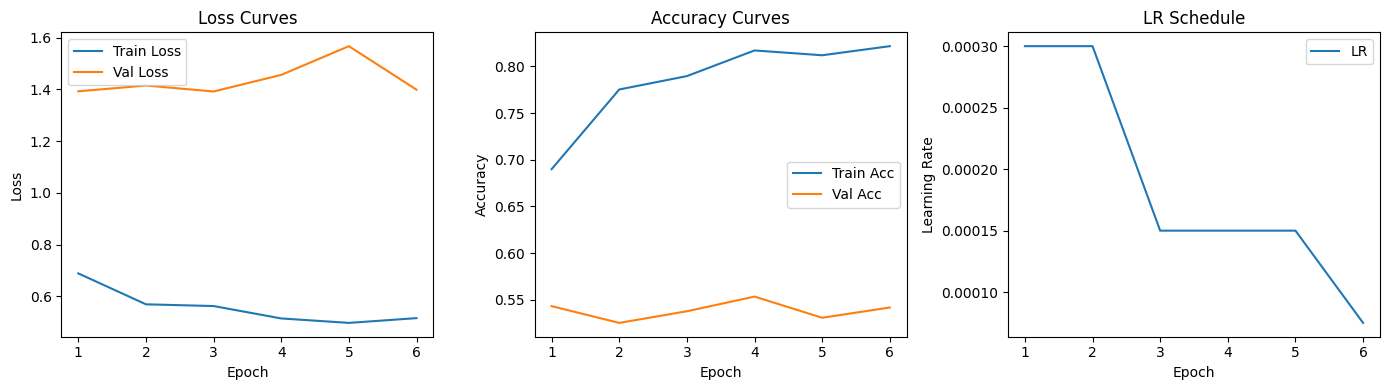

In [20]:
# Inspect learning dynamics
if len(history["train_loss"]) > 0:
    epochs_axis = np.arange(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(14, 4))
    plt.subplot(1, 3, 1)
    plt.plot(epochs_axis, history["train_loss"], label="Train Loss")
    plt.plot(epochs_axis, history["val_loss"], label="Val Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Loss Curves")
    plt.legend()

    plt.subplot(1, 3, 2)
    plt.plot(epochs_axis, history["train_acc"], label="Train Acc")
    plt.plot(epochs_axis, history["val_acc"], label="Val Acc")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Accuracy Curves")
    plt.legend()

    plt.subplot(1, 3, 3)
    plt.plot(epochs_axis, history["lr"], label="LR")
    plt.xlabel("Epoch")
    plt.ylabel("Learning Rate")
    plt.title("LR Schedule")
    plt.legend()

    plt.tight_layout()
    plt.show()

# Optional debug: if val is still ~0.5, run this to verify the model can overfit one batch.
def overfit_single_batch(model, loader, criterion, optimizer, device, steps=100):
    model.train()
    x, y = next(iter(loader))
    x, y = x.to(device), y.to(device)

    for step in range(steps):
        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        if (step + 1) % 20 == 0:
            with torch.no_grad():
                preds = torch.argmax(logits, dim=1)
                acc = (preds == y).float().mean().item()
            print(f"Step {step+1}/{steps} | Loss: {loss.item():.4f} | Batch Acc: {acc:.4f}")

In [21]:
# Fast sanity test: model should overfit a single batch if pipeline is healthy
debug_model = TemporalHybridModel(
    num_classes=len(class_names),
    fft_dim=FFT_DIM,
    lstm_hidden=LSTM_HIDDEN,
    freeze_backbones=FREEZE_BACKBONES,
    temporal_pool=TEMPORAL_POOL,
).to(DEVICE)

debug_criterion = nn.CrossEntropyLoss()
debug_optimizer = torch.optim.AdamW(
    [p for p in debug_model.parameters() if p.requires_grad],
    lr=1e-3,
    weight_decay=0.0,
 )

overfit_single_batch(
    debug_model,
    train_loader,
    debug_criterion,
    debug_optimizer,
    DEVICE,
    steps=30,
 )

Step 20/30 | Loss: 0.0000 | Batch Acc: 1.0000


In [ ]:
# Final validation metrics
if Path(best_ckpt).exists():
    loaded = torch.load(best_ckpt, map_location=DEVICE)
    if isinstance(loaded, dict) and "model_state_dict" in loaded:
        model.load_state_dict(loaded["model_state_dict"], strict=False)
    else:
        model.load_state_dict(loaded, strict=False)
    print("Loaded best checkpoint for final metrics:", best_ckpt)
else:
    print("Best checkpoint not found; evaluating current in-memory model.")

val_loss, val_acc, labels_all, preds_all, probs_all = evaluate(model, val_loader, criterion, DEVICE)

precision = precision_score(labels_all, preds_all, average="weighted", zero_division=0)
recall = recall_score(labels_all, preds_all, average="weighted", zero_division=0)
f1 = f1_score(labels_all, preds_all, average="weighted", zero_division=0)

pred_counts = np.bincount(np.array(preds_all, dtype=np.int64), minlength=len(class_names))
label_counts = np.bincount(np.array(labels_all, dtype=np.int64), minlength=len(class_names))

print("\n===== MODEL PERFORMANCE =====")
print("Accuracy:", val_acc)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print("Label counts:", {class_names[i]: int(label_counts[i]) for i in range(len(class_names))})
print("Pred counts:", {class_names[i]: int(pred_counts[i]) for i in range(len(class_names))})

print("\n===== CLASSIFICATION REPORT =====")
print(classification_report(labels_all, preds_all, target_names=class_names, zero_division=0))

Loaded best checkpoint for final metrics: small_cnn_vit_fft_lstm_model.pth



===== MODEL PERFORMANCE =====
Accuracy: 0.5534407027818448
Precision: 0.6145236476339302
Recall: 0.5534407027818448
F1 Score: 0.5399061205143921
Label counts: {'fake': 1154, 'real': 1578}
Pred counts: {'fake': 1884, 'real': 848}

===== CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

        fake       0.48      0.79      0.60      1154
        real       0.71      0.38      0.50      1578

    accuracy                           0.55      2732
   macro avg       0.60      0.58      0.55      2732
weighted avg       0.61      0.55      0.54      2732



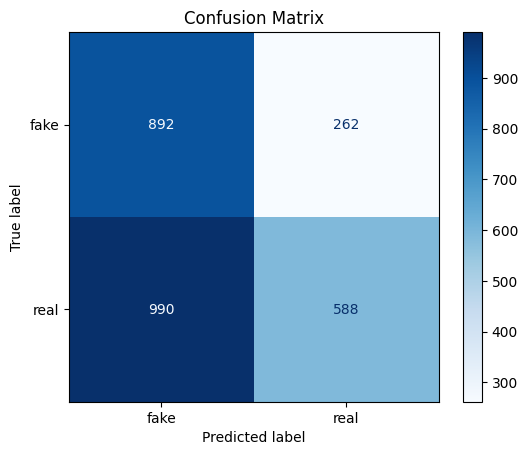

In [12]:
cm = confusion_matrix(labels_all, preds_all)
disp = ConfusionMatrixDisplay(cm, display_labels=class_names)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

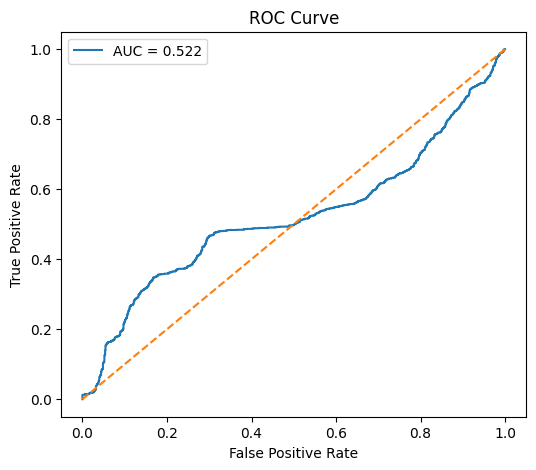

In [13]:
# ROC (binary only)
if len(class_names) == 2 and len(probs_all) == len(labels_all):
    fpr, tpr, _ = roc_curve(labels_all, probs_all)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend()
    plt.show()
else:
    print("ROC is only shown for binary classification.")